In [346]:
import rosbag
import matplotlib.pyplot as plt
import numpy as np
import math
import utm



In [347]:
SPEED_THRESHOLD = 0.5  # m/s
HORIZONTAL = np.array([1, 0])

In [348]:
def load_poses(bag, plot):

    times = []
    ego_poses = []

    if plot:
        plt.figure(figsize=(15, 15))

    for topic, msg, t in bag.read_messages(topics=["/gps_info"]):

        utm_values = utm.from_latlon(msg.lat, msg.lon)
        yaw_rad = (math.pi / 2) - msg.track * math.pi / 180
        ego_pose = [utm_values[0], utm_values[1], yaw_rad, msg.speed]
        ego_poses.append(ego_pose)
        times.append(t.to_sec())
        
        if plot:
            plt.scatter(utm_values[0], utm_values[1])
            plt.plot([utm_values[0], utm_values[0] + 0.1 * np.cos(yaw_rad)], [utm_values[1], utm_values[1] + 0.1 * np.sin(yaw_rad)])

    if plot:
        plt.xlabel("x")
        plt.ylabel("y")
        plt.axis("equal")
        plt.show()

    return times, ego_poses

def compute_centers(times, ego_poses, orientation_factor, radius, correction_angle, plot):

    if plot:
        plt.figure(figsize=(15, 15))

    discarded_gps_center_positions = []
    selected_gps_center_positions = []

    selected_times = []
    selected_ego_poses = []
    discarded_ego_poses = []

    for time, ego_pose in zip(times, ego_poses):

        ego_x = ego_pose[0]
        ego_y = ego_pose[1]
        yaw_rad = ego_pose[2]
        speed = ego_pose[3]

        gps_normal = np.array([np.sin(yaw_rad), -np.cos(yaw_rad)])
        gps_center = np.array([
            ego_x + orientation_factor * radius * gps_normal[0],
            ego_y + orientation_factor * radius * gps_normal[1],
        ])

        if speed < SPEED_THRESHOLD:
            discarded_gps_center_positions.append(gps_center)
            discarded_ego_poses.append(ego_pose)
            print(f"discaring message at t={time}")
        else:
            selected_times.append(time)
            selected_ego_poses.append(ego_pose)
            selected_gps_center_positions.append(gps_center)

    center_of_selected_centers = [
        np.mean(np.asarray(selected_gps_center_positions)[:, 0]),
        np.mean(np.asarray(selected_gps_center_positions)[:, 1]),
    ]

    if plot:
        plt.scatter([elem[0] for elem in selected_ego_poses],
                    [elem[1] for elem in selected_ego_poses],
                    c=range(len(selected_ego_poses)),
                    cmap='Blues',
                    label="selected ego poses"
        )
        plt.scatter([elem[0] for elem in discarded_ego_poses],
            [elem[1] for elem in discarded_ego_poses],
            c=range(len(discarded_ego_poses)),
            cmap='Reds',
            label="discarded ego poses"

            )
        for selected_ego_pose in selected_ego_poses:
            plt.plot([selected_ego_pose[0], selected_ego_pose[0] + 0.1 * np.cos(selected_ego_pose[2])], [selected_ego_pose[1], selected_ego_pose[1] + 0.1 * np.sin(selected_ego_pose[2])], color="blue")
        for discarded_ego_pose in discarded_ego_poses:
            plt.plot([discarded_ego_pose[0], discarded_ego_pose[0] + 0.1 * np.cos(discarded_ego_pose[2])], [discarded_ego_pose[1], discarded_ego_pose[1] + 0.1 * np.sin(discarded_ego_pose[2])], color="red")
        
        plt.scatter([elem[0] for elem in selected_gps_center_positions],
                    [elem[1] for elem in selected_gps_center_positions],
                    c=range(len(selected_gps_center_positions)),
                    cmap='Blues',
                    marker="+",
            label="selected centers"

        )
        plt.scatter([elem[0] for elem in discarded_gps_center_positions],
            [elem[1] for elem in discarded_gps_center_positions],
            c=range(len(discarded_gps_center_positions)),
            cmap='Reds',
            marker="+",
            label="discarded centers"
            )
        plt.scatter(center_of_selected_centers[0], center_of_selected_centers[1], color="green", label="center of selected centers")
        plt.axis("equal")
        plt.legend()
        plt.xlabel("x")
        plt.ylabel("y")
        plt.show()

    return selected_times, selected_ego_poses, selected_gps_center_positions, center_of_selected_centers


def foo(selected_times, selected_ego_poses, center_of_selected_centers, orientation_factor, plot):        

    geometric_angles = []  # to store the angles between the horizontal and the end of the stick (same as COG), computed geometrically
    geometric_angle_derivatives = []
    gps_angles = []  # to store the COG we get directly from the GPS 
    gps_angle_derivatives = []
    angle_diffs = []

    for time, ego_pose in zip(selected_times, selected_ego_poses):

        ego_x = ego_pose[0]
        ego_y = ego_pose[1]
        yaw_rad = ego_pose[2]

        vec_from_center_of_centers = -np.array([center_of_selected_centers[0] - ego_x,
                                    center_of_selected_centers[1] - ego_y])

        
        
        geometric_angle = (-orientation_factor * np.pi / 2 + np.arctan2(HORIZONTAL[0] * vec_from_center_of_centers[1] - HORIZONTAL[1] * vec_from_center_of_centers[0], HORIZONTAL[0]*vec_from_center_of_centers[0]+HORIZONTAL[1]*vec_from_center_of_centers[1])) % (2*np.pi)
        gps_angle = yaw_rad % (2*np.pi)

        if len(geometric_angles):
            geometric_angle_derivative = (geometric_angle - geometric_angles[-1]) / 0.1
            if abs(geometric_angle_derivative) > 10:  # hack-ish to not have crazy values when going from 2*pi to 0
                geometric_angle_derivatives.append(None)
            else: 
                geometric_angle_derivatives.append(geometric_angle_derivative)

        if len(gps_angles):
            gps_angle_derivative = (gps_angle - gps_angles[-1]) / 0.1
            if abs(gps_angle_derivative) > 10:  # hack-ish to not have crazy values when going from 2*pi to 0
                gps_angle_derivatives.append(None)
            else: 
                gps_angle_derivatives.append(gps_angle_derivative)

        geometric_angles.append(geometric_angle)
        gps_angles.append(gps_angle)
        angle_diffs.append(yaw_rad - geometric_angle)


    if plot:
        plt.figure(figsize=(15, 15))
        plt.plot(selected_times, geometric_angles, label="geometric angles")
        plt.plot(selected_times, gps_angles, label="GPS angles")
        plt.xlabel("t (s)")
        plt.ylabel("angle (rad)")
        plt.legend()
        plt.show()

        plt.figure(figsize=(15, 15))
        plt.plot(selected_times[1:], geometric_angle_derivatives, label="angular velocity (geometric)")
        plt.plot(selected_times[1:], gps_angle_derivatives, label="angular velocity (GPS)")
        plt.xlabel("t (s)")
        plt.ylabel("angular velocity (rad/s)")
        plt.legend()
        plt.show()

        plt.figure(figsize=(15, 15))
        plt.plot([elem for elem in angle_diffs if abs(elem) < 1], label="angle diff between geometric and GPS")  # the < 1 is here to not consider the points where there is the jump from 0 to 2*pi
        plt.xlabel("t (s)")
        plt.ylabel("angular difference (rad)")
        plt.legend()
        plt.show()

        plt.figure(figsize=(15, 15))
        plt.hist([elem for elem in angle_diffs if abs(elem) < 1])  # the < 1 is here to not consider the points where there is the jump from 0 to 2*pi
        plt.xlabel("angular difference (rad)")
        plt.ylabel("count")
        plt.show()




In [349]:
baseline_1 = "/Users/antoineroux/Downloads/bags_gps_2024-05-12/baseline_slow_2024-05-12-22-30-37.bag"
baseline_2 = "/Users/antoineroux/Downloads/bags_gps_2024-05-12/baseline_slow_2024-05-12-22-32-22.bag"
baseline_3 = "/Users/antoineroux/Downloads/bags_gps_2024-05-12/baseline_fast_2024-05-12-22-33-51.bag"
baseline_4 = "/Users/antoineroux/Downloads/bags_gps_2024-05-12/baseline_fast_2024-05-12-22-37-00.bag"

vehicle_1 = "/Users/antoineroux/Downloads/bags_gps_2024-05-12/badynamic_slow_2024-05-12-22-48-36.bag"
vehicle_2 = "/Users/antoineroux/Downloads/bags_gps_2024-05-12/dynamic_slow_2024-05-12-22-51-39.bag"
vehicle_3 = "/Users/antoineroux/Downloads/bags_gps_2024-05-12/dynamic_fast_2024-05-12-22-52-53.bag"
vehicle_4 = "/Users/antoineroux/Downloads/bags_gps_2024-05-12/dynamic_slow_2024-05-12-22-54-05.bag"

low_pass_08_1 = "/Users/antoineroux/Downloads/bags_gps_2024-05-12/cog_low_pass_0.8_slow_2024-05-12-23-16-25.bag"
low_pass_08_2 = "/Users/antoineroux/Downloads/bags_gps_2024-05-12/cog_low_pass_0.8_slow_2024-05-12-23-17-58.bag"
low_pass_08_3 = "/Users/antoineroux/Downloads/bags_gps_2024-05-12/cog_low_pass_0.8_fast_2024-05-12-23-19-35.bag"
low_pass_08_4 = "/Users/antoineroux/Downloads/bags_gps_2024-05-12/cog_low_pass_0.8_fast_2024-05-12-23-20-19.bag"

low_pass_05_1 = "/Users/antoineroux/Downloads/bags_gps_2024-05-12/cog_low_pass_0.5_slow_2024-05-12-23-28-26.bag"
low_pass_05_2 = "/Users/antoineroux/Downloads/bags_gps_2024-05-12/cog_low_pass_0.5_slow_2024-05-12-23-29-09.bag"
low_pass_05_3 = "/Users/antoineroux/Downloads/bags_gps_2024-05-12/cog_low_pass_0.5_slow_after_restart_pos_mode_F_2024-05-12-23-59-59.bag"
low_pass_05_4 = "/Users/antoineroux/Downloads/bags_gps_2024-05-12/cog_low_pass_0.5_fast_after_restart_pos_mode_F_2024-05-13-00-00-49.bag"

low_pass_02_1 = "/Users/antoineroux/Downloads/bags_gps_2024-05-12/cog_low_pass_0.2_slow_2024-05-12-23-05-20.bag"
low_pass_02_2 = "/Users/antoineroux/Downloads/bags_gps_2024-05-12/cog_low_pass_0.2_slow_2024-05-12-23-08-23.bag"
low_pass_02_3 = "/Users/antoineroux/Downloads/bags_gps_2024-05-12/cog_low_pass_0.2_fast_2024-05-12-23-09-24.bag"
low_pass_02_4 = "/Users/antoineroux/Downloads/bags_gps_2024-05-12/cog_low_pass_0.2_fast_2024-05-12-23-10-31.bag"


In [350]:
bag = rosbag.Bag(baseline_3)
# bag = rosbag.Bag(low_pass_05_4)

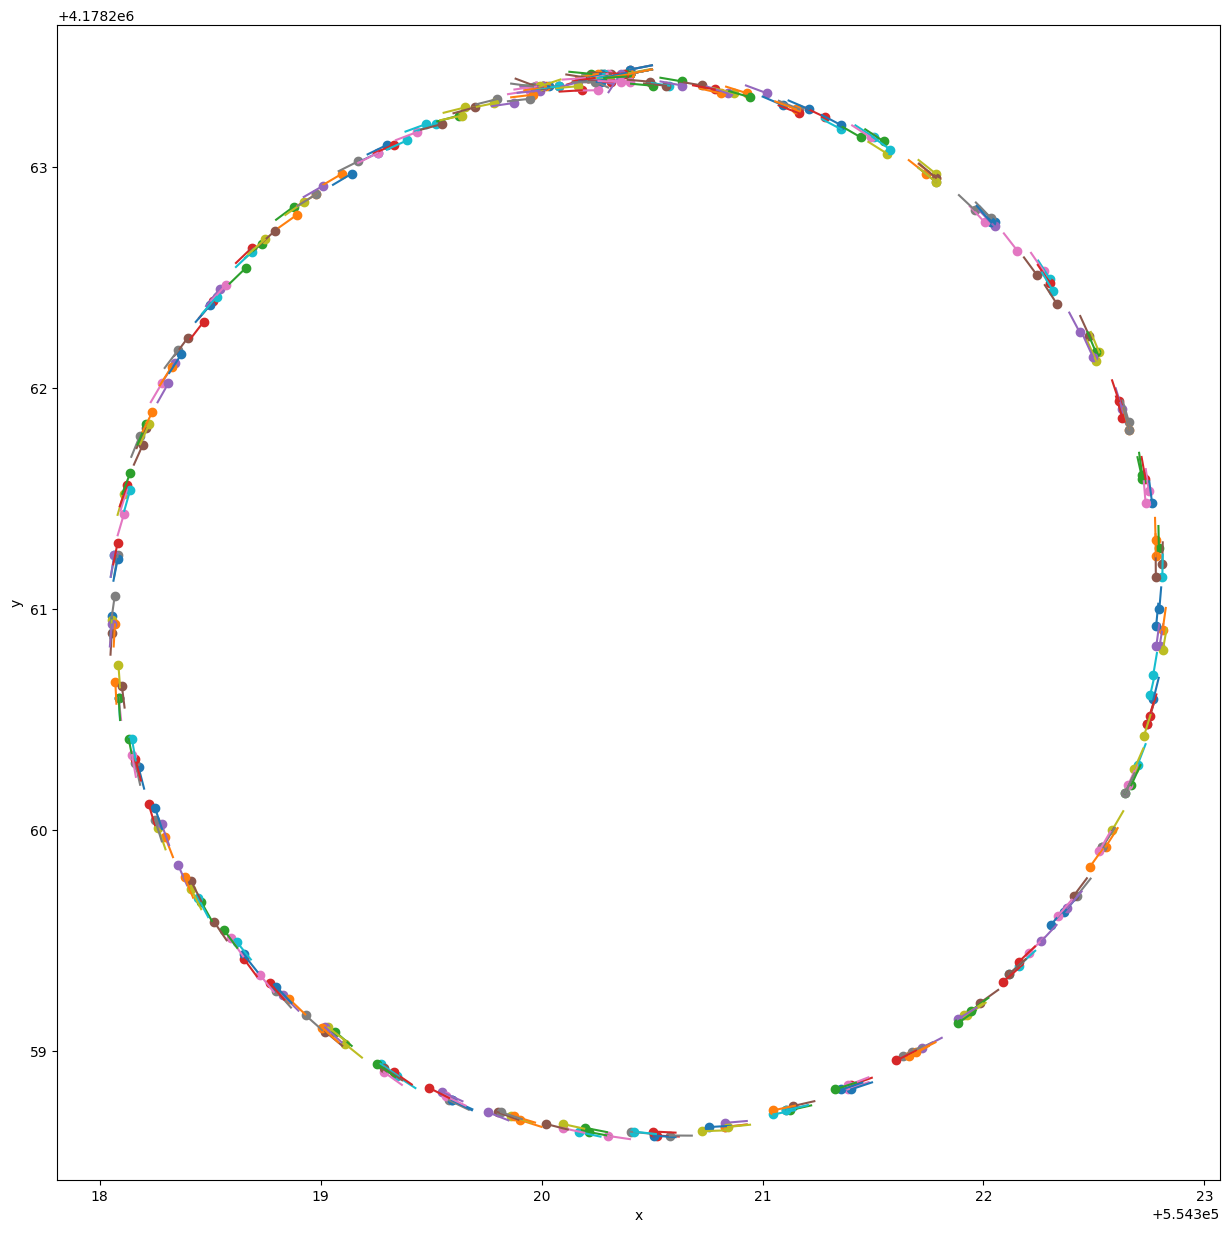

discaring message at t=1715553232.1174839
discaring message at t=1715553232.209357
discaring message at t=1715553232.3094258
discaring message at t=1715553232.4116955
discaring message at t=1715553232.51761
discaring message at t=1715553232.616464
discaring message at t=1715553232.7093654
discaring message at t=1715553232.8068802
discaring message at t=1715553232.9068985
discaring message at t=1715553233.0146146
discaring message at t=1715553233.1120765
discaring message at t=1715553233.2074866
discaring message at t=1715553233.3108726
discaring message at t=1715553233.4091568
discaring message at t=1715553233.514783
discaring message at t=1715553233.7052991
discaring message at t=1715553233.8057177
discaring message at t=1715553233.9075985
discaring message at t=1715553234.0172012
discaring message at t=1715553234.1134317
discaring message at t=1715553234.211342
discaring message at t=1715553234.412308
discaring message at t=1715553234.510068
discaring message at t=1715553234.6053736


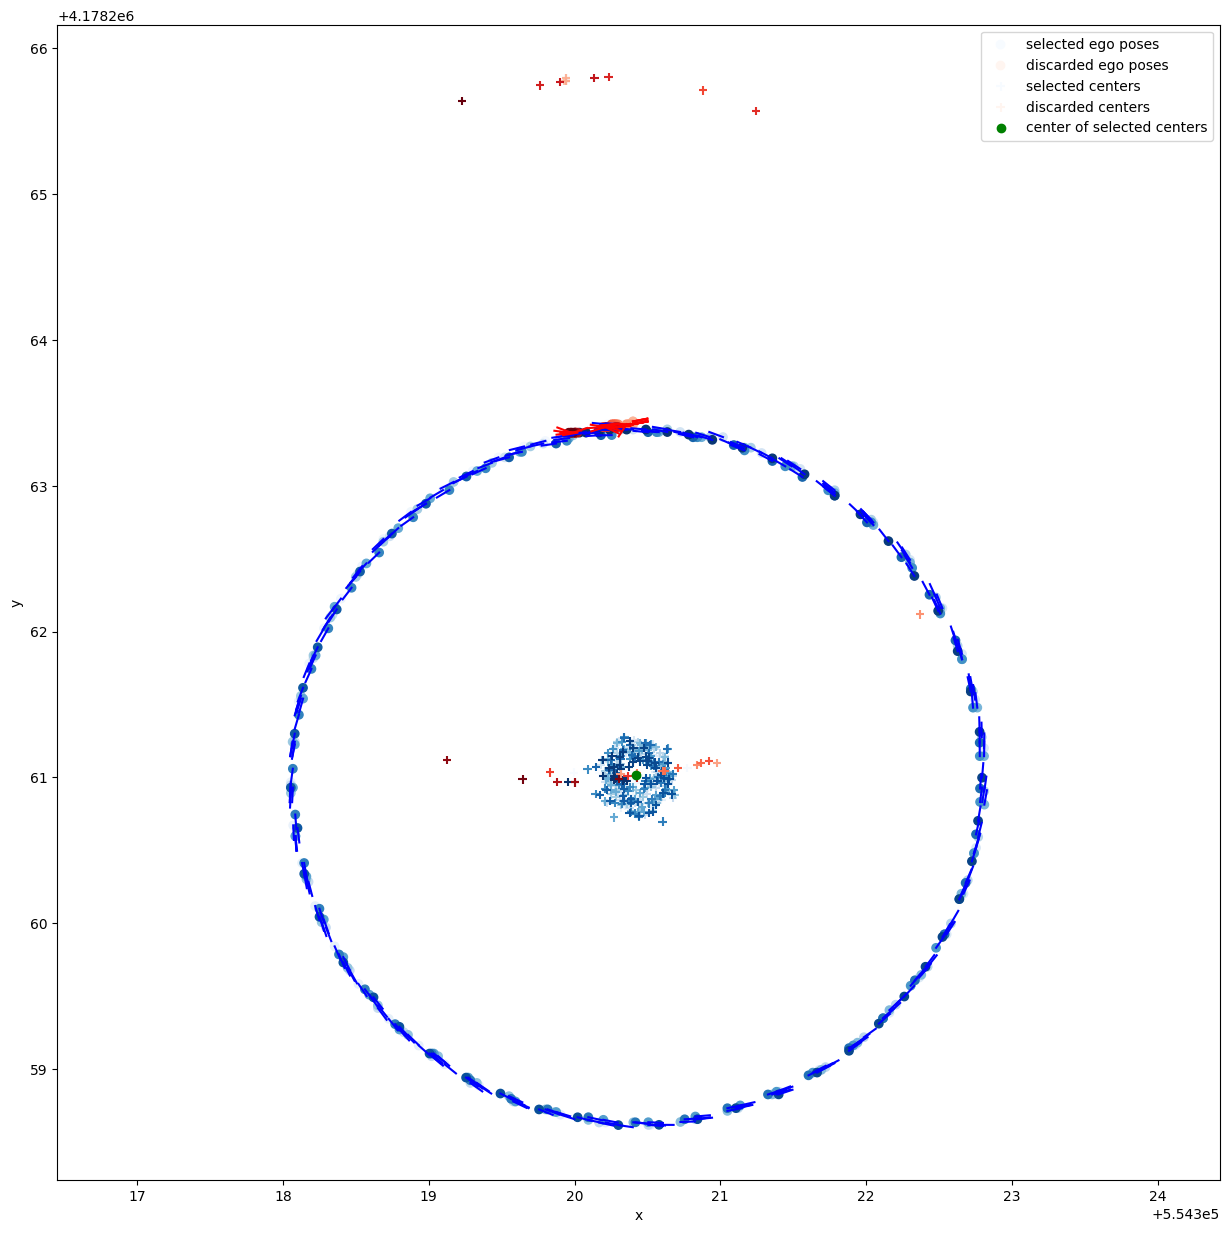

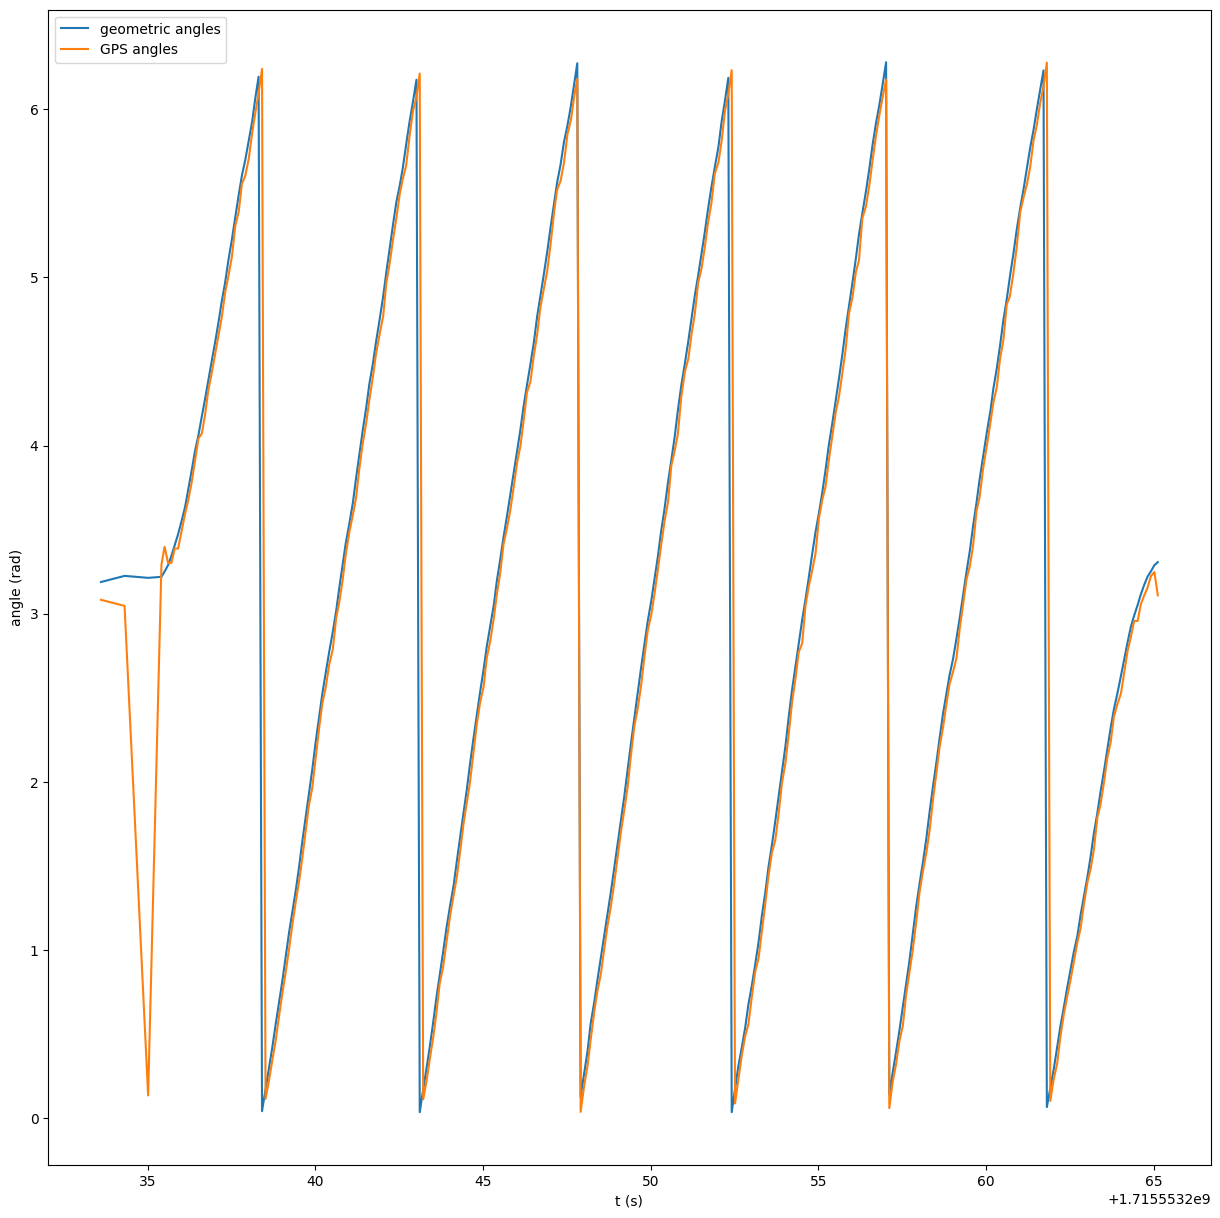

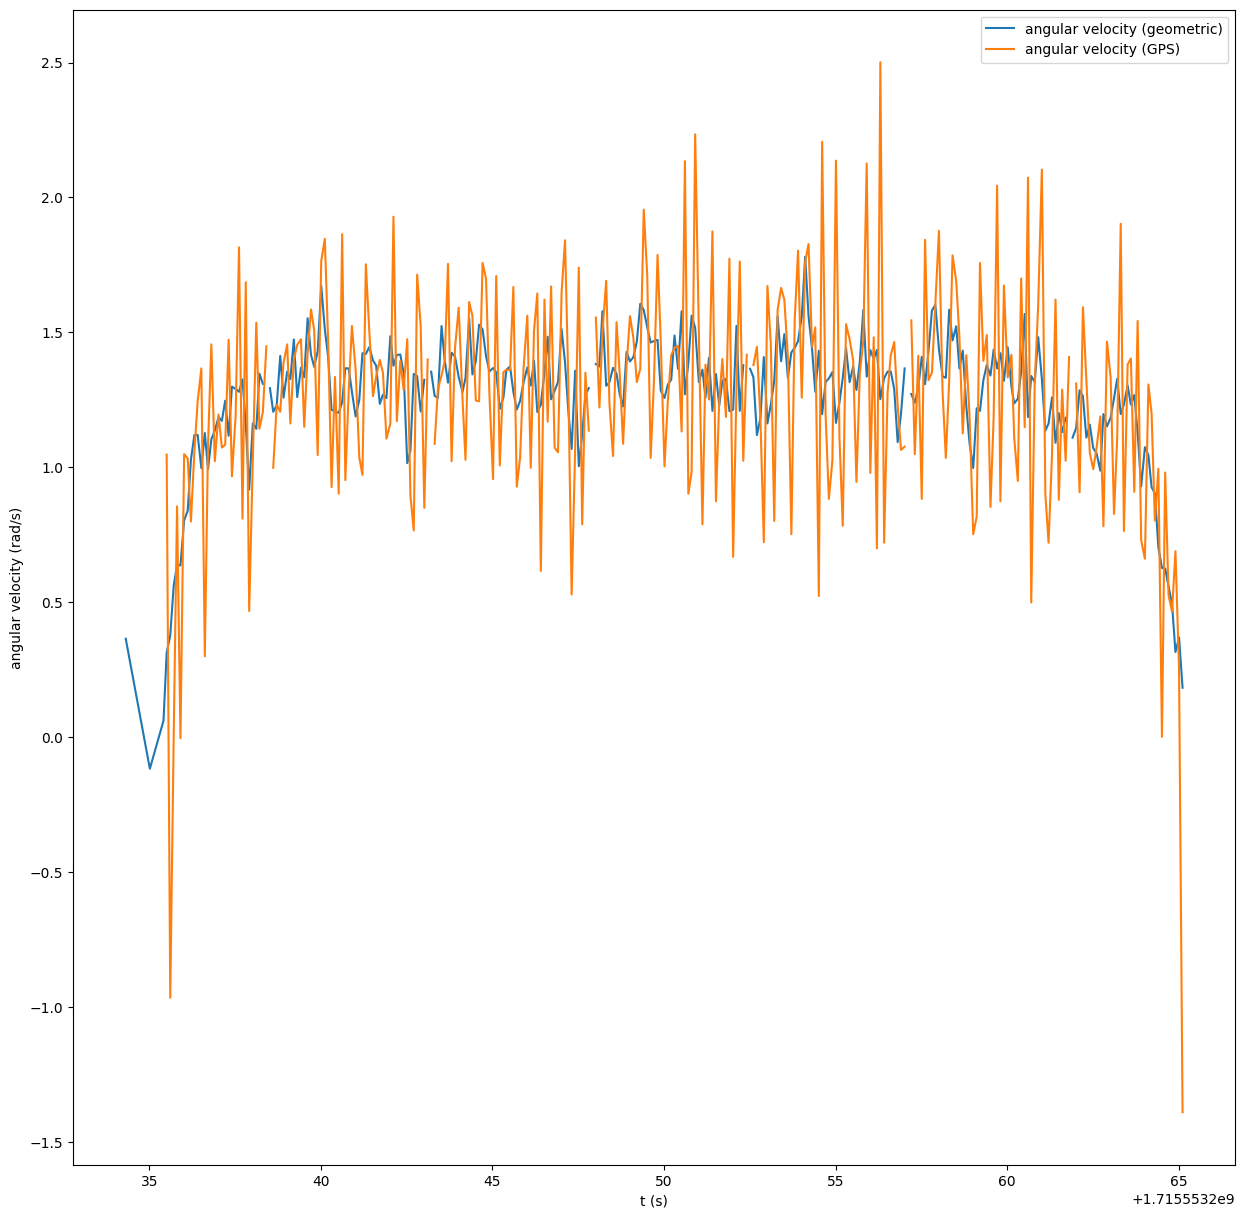

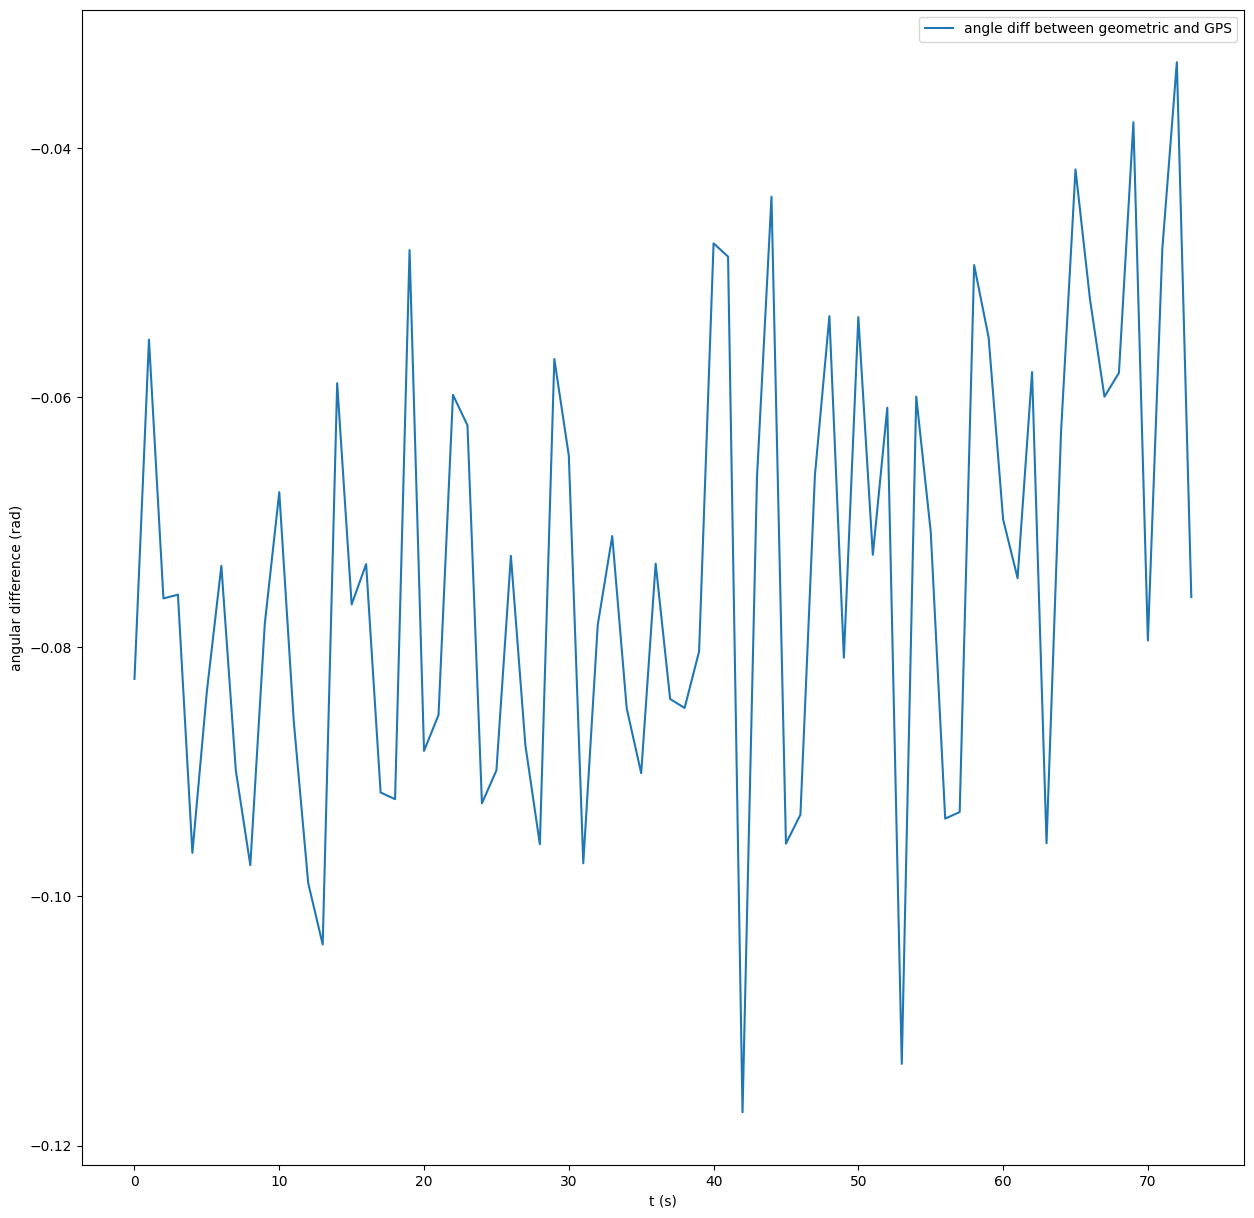

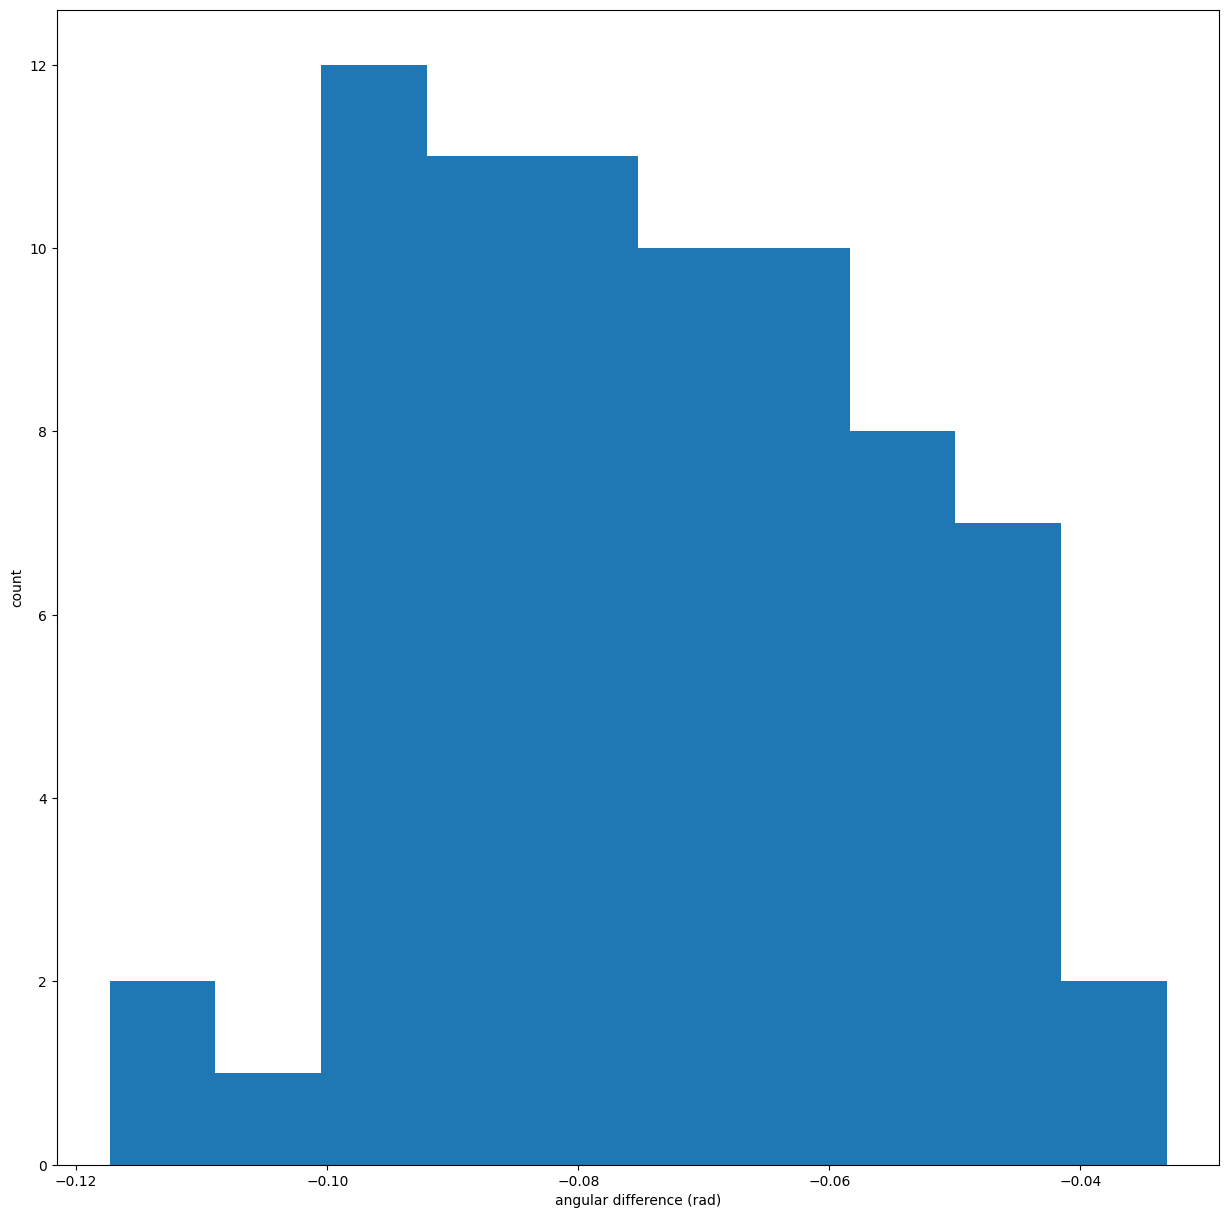

In [351]:
times, ego_poses = load_poses(bag=bag, plot=True)

selected_times, selected_ego_poses, selected_gps_center_positions, center_of_selected_centers = compute_centers(times, ego_poses, -1, 2.4, 0, True)
foo(selected_times, selected_ego_poses, center_of_selected_centers, -1, True)

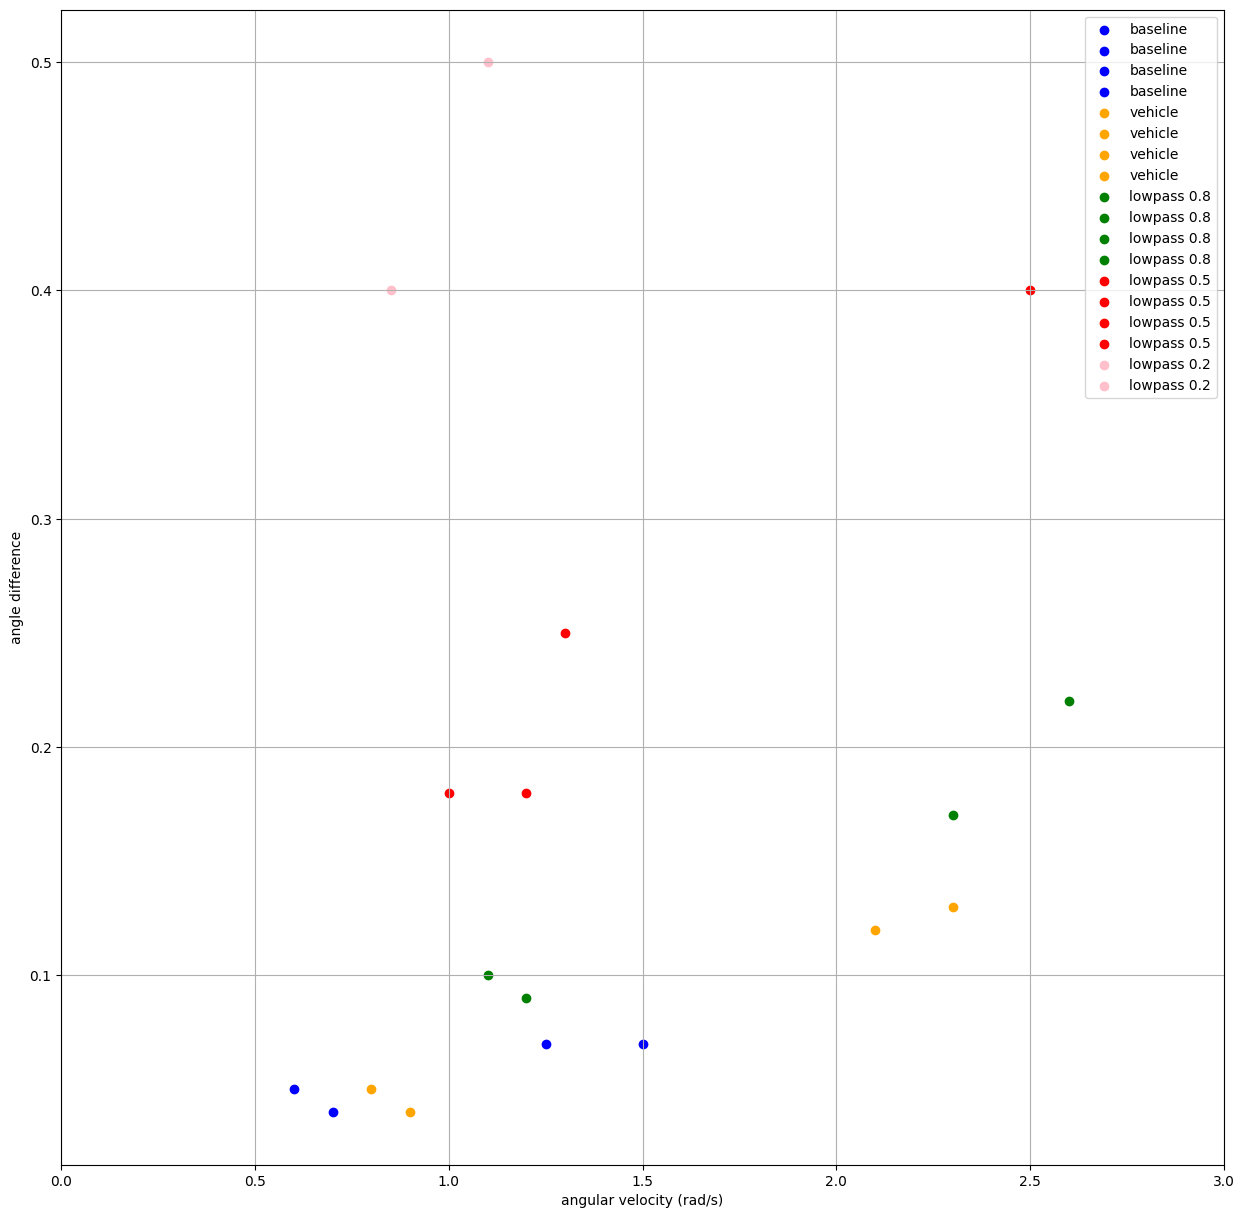

In [352]:
# Manually measured theta_diff for different angular velocities for the bags

# baseline
# w          0.60 0.70 1.25 1.50
# theta_diff 0.05 0.04 0.07 0.07

# vehicle
# w          2.10 0.90 2.30 0.80
# theta_diff 0.12 0.04 0.13 0.05

# lowpass 0.8
# w          2.60 2.30 1.10 1.20
# theta_diff 0.22 0.17 0.10 0.09

# lowpass 0.5
# w          1.30 1.20 2.50 1.00
# theta_diff 0.25 0.18 0.40 0.18

# lowpass 0.2
# w          0.85 1.10
# theta_diff 0.40 0.50

plt.figure(figsize=(15, 15))
plt.scatter(0.60, 0.05, color="blue", label="baseline")
plt.scatter(0.70, 0.04, color="blue", label="baseline")
plt.scatter(1.25, 0.07, color="blue", label="baseline")
plt.scatter(1.50, 0.07, color="blue", label="baseline")

plt.scatter(2.10, 0.12, color="orange", label="vehicle")
plt.scatter(0.90, 0.04, color="orange", label="vehicle")
plt.scatter(2.30, 0.13, color="orange", label="vehicle")
plt.scatter(0.80, 0.05, color="orange", label="vehicle")

plt.scatter(2.60, 0.22, color="green", label="lowpass 0.8")
plt.scatter(2.30, 0.17, color="green", label="lowpass 0.8")
plt.scatter(1.10, 0.10, color="green", label="lowpass 0.8")
plt.scatter(1.20, 0.09, color="green", label="lowpass 0.8")

plt.scatter(1.30, 0.25, color="red", label="lowpass 0.5")
plt.scatter(1.20, 0.18, color="red", label="lowpass 0.5")
plt.scatter(2.50, 0.40, color="red", label="lowpass 0.5")
plt.scatter(1.00, 0.18, color="red", label="lowpass 0.5")

plt.scatter(0.85, 0.40, color="pink", label="lowpass 0.2")
plt.scatter(1.10, 0.50, color="pink", label="lowpass 0.2")

plt.xlim([0, 3])
plt.xlabel("angular velocity (rad/s)")
plt.ylabel("angle difference")
plt.legend()
plt.grid()
plt.show()

# max angular velocity for a 3m radius turn at 9m/s^2 acceleration = 1.75 rad/s

In [353]:
import math
import numpy as np
from typing import List

MIN_CURVATURE = 0.3  # m
MAX_CURVATURE = 100000  # m


class State:
    def __init__(
        self,
        x: float = 0,
        y: float = 0,
        z: float = 0,
        vx: float = 0,
        vy: float = 0,
        vz: float = 0,
        angle: float = 0,
    ):
        self.x = x
        self.y = y
        self.z = z
        self.vx = vx
        self.vy = vy
        self.vz = vz
        self.angle = angle


def compute_curvature(current_state: State, target_state: State):
    """
    Compute the curvature of the circle passing through the current_state and the target_state, tangent to the direction of the car
    See the document pure_pursuit.pdf for the derivation

    Args:
        current_state: State representing the current state of the vehicle, with at least x, y and angle
        line_vector: List of the components of the vector defining the line direction

    Returns:
        float: the curvature
    """
    # Computing the norm of the curvature
    orthogonal_vector = [
        -np.sin(current_state.angle),
        np.cos(current_state.angle),
    ]
    d = distance_point_to_line(current_state, orthogonal_vector, target_state)
    D = plane_distance(current_state, target_state)

    curvature_norm = 2 * np.sqrt(D**2 - d**2) / D**2

    # Computing the sign of the curvature
    car_direction_vector = np.array(
        [
            np.cos(current_state.angle),
            np.sin(current_state.angle),
        ]
    )
    target_direction_vector = np.array(
        [target_state.x - current_state.x, target_state.y - current_state.y]
    )
    sign = np.sign(np.cross(car_direction_vector, target_direction_vector))

    return sign * curvature_norm


def distance_point_to_line(
    current_state: State, line_vector: List[int], target_state: State
):
    """
    Compute the distance between the target state and the line defined by the current state and the line_vector

    Args:
        current_state: State representing the current state of the vehicle, with at least x and y
        line_vector: List of the components of the vector defining the line direction
        target state: State representing the target point, with at least x and y

    Returns:
        float: the distance
    """
    current_state_point = np.array([current_state.x, current_state.y])
    target_state_point = np.array([target_state.x, target_state.y])
    line_vector = np.array(line_vector)

    target_to_current_vector = target_state_point - current_state_point

    distance = np.linalg.norm(
        (target_to_current_vector)
        - np.dot((target_to_current_vector), line_vector) * line_vector
    )
    return distance


def plane_distance(current_state: State, target_state: State):
    """
    Returns the distance between two points on the xy plane

    Args:
        current_state: State representing the current state of the vehicle, with at least x, y and angle
        target state: State representing the target point, with at least x and y

    Returns:
        float: the distance
    """
    return math.sqrt(
        (target_state.x - current_state.x) ** 2
        + (target_state.y - current_state.y) ** 2
    )


def compute_steering_angle_from_curvature(curvature: float, wheel_base: float):
    """
    Compute the steering angle required to drive on a circle of a given curvature, assuming a bicycle model

    Args:
        curvature: the curvature of the circle to drive on
        wheel_base: wheel base of the vehicle

    Returns:
        float: the steering angle
    """

    return np.arctan(curvature * wheel_base)


def circle_line_segment_intersection(
    circle_center: List[float],
    circle_radius: float,
    pt1: List[float],
    pt2: List[float],
    full_line: bool = True,
    tangent_tol: float = 1e-9,
):
    """Find the points at which a circle intersects a line-segment.  This can happen at 0, 1, or 2 points.

    :param circle_center: The (x, y) location of the circle center
    :param circle_radius: The radius of the circle
    :param pt1: The (x, y) location of the first point of the segment
    :param pt2: The (x, y) location of the second point of the segment
    :param full_line: True to find intersections along full line - not just in the segment.  False will just return intersections within the segment.
    :param tangent_tol: Numerical tolerance at which we decide the intersections are close enough to consider it a tangent
    :return Sequence[Tuple[float, float]]: A list of length 0, 1, or 2, where each element is a point at which the circle intercepts a line segment.

    Note: We follow: http://mathworld.wolfram.com/Circle-LineIntersection.html
    """

    (p1x, p1y), (p2x, p2y), (cx, cy) = pt1, pt2, circle_center
    (x1, y1), (x2, y2) = (p1x - cx, p1y - cy), (p2x - cx, p2y - cy)
    dx, dy = (x2 - x1), (y2 - y1)
    dr = (dx**2 + dy**2) ** 0.5
    big_d = x1 * y2 - x2 * y1
    discriminant = circle_radius**2 * dr**2 - big_d**2

    if discriminant < 0:  # No intersection between circle and line
        return []
    else:  # There may be 0, 1, or 2 intersections with the segment
        intersections = [
            (
                cx
                + (big_d * dy + sign * (-1 if dy < 0 else 1) * dx * discriminant**0.5)
                / dr**2,
                cy + (-big_d * dx + sign * abs(dy) * discriminant**0.5) / dr**2,
            )
            for sign in ((1, -1) if dy < 0 else (-1, 1))
        ]
        # This makes sure the order along the segment is correct
        if not full_line:
            # If only considering the segment, filter out intersections that do not fall within the segment
            fraction_along_segment = [
                (xi - p1x) / dx if abs(dx) > abs(dy) else (yi - p1y) / dy
                for xi, yi in intersections
            ]
            intersections = [
                pt
                for pt, frac in zip(intersections, fraction_along_segment)
                if 0 <= frac <= 1
            ]
        if len(intersections) == 2 and abs(discriminant) <= tangent_tol:
            # If line is tangent to circle, return just one point (as both intersections have same location)
            return [intersections[0]]
        else:
            return intersections


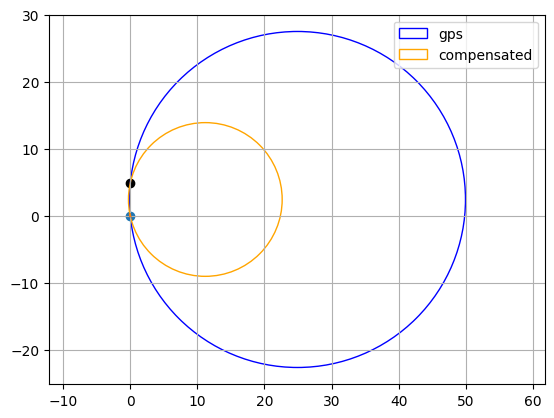

pwm_cmd_diff_baseline:    -2.9
pwm_cmd_diff_compensated: -6.2
diff                      3.4


In [397]:

STEERING_IDLE_PWM = 98  # unitless
STEERING_MAX_PWM = 123  # unitless
STEERING_MIN_PWM = 68  # unitless
UPPER_BOUND_REGION_1 = 1.5  # m/s
UPPER_BOUND_REGION_2 = 5  # m/s
UPPER_BOUND_REGION_3 = 8  # m/s
COEFF_REGION_1 = 27 * 1.25  # max steering_diff * radius of circle at max lateral acceleration
COEFF_REGION_2 = 24 * 2.3
COEFF_REGION_3 = 26 * 4

def compute_effect(ego_state, target_point, angle_offset):
    curvature_baseline = compute_curvature(
        current_state=ego_state, target_state=target_point
    )
    curvature_baseline = compute_curvature(
        current_state=ego_state, target_state=target_point
    )
    
    compensated_ego_state = State(vx=ego_state.vx, angle=ego_state.angle + angle_offset)
    curvature_compensated = compute_curvature(
        current_state=compensated_ego_state, target_state=target_point
    )


    if ego_state.vx == 0:
        coeff = 1000  # just so that we get a small number later on
    elif ego_state.vx > 0 and ego_state.vx <= UPPER_BOUND_REGION_1:
        coeff = 1 / (
            COEFF_REGION_1
        )
    elif ego_state.vx > UPPER_BOUND_REGION_1 and ego_state.vx <= UPPER_BOUND_REGION_2:
        coeff = 1 / (
            COEFF_REGION_1
            + (ego_state.vx - UPPER_BOUND_REGION_1)
            * (COEFF_REGION_2 - COEFF_REGION_1)
            / (UPPER_BOUND_REGION_2 - UPPER_BOUND_REGION_1)
        )
    elif ego_state.vx > UPPER_BOUND_REGION_2 and ego_state.vx <= UPPER_BOUND_REGION_3:
        coeff = 1 / (
            COEFF_REGION_2
            + (ego_state.vx - UPPER_BOUND_REGION_2) * (COEFF_REGION_3 - COEFF_REGION_2) / (UPPER_BOUND_REGION_3 - UPPER_BOUND_REGION_2)
        )
    elif ego_state.vx > UPPER_BOUND_REGION_3:
        coeff = 1 / COEFF_REGION_3

    pwm_cmd_diff_baseline =  curvature_baseline / coeff
    pwm_cmd_diff_compensated =  curvature_compensated / coeff

    diff = pwm_cmd_diff_baseline - pwm_cmd_diff_compensated

    fig, ax = plt.subplots()

    plt.scatter(ego_state.x, ego_state.y)
    plt.plot([ego_state.x, ego_state.x + 0.3 * np.cos(ego_angle)], [ego_state.y, ego_state.y + 0.3 * np.sin(ego_angle)])
    plt.plot([ego_state.x, ego_state.x + 0.3 * np.cos(ego_angle+angle_offset)], [ego_state.y, ego_state.y + 0.3 * np.sin(ego_angle+angle_offset)])
    plt.scatter(target_point.x, target_point.y, color="k")

    center_baseline = (
        ego_state.x + -1 * 1 / curvature_baseline * np.cos(ego_angle - np.pi / 2),
        ego_state.y + -1 * 1 / curvature_baseline * np.sin(ego_angle - np.pi / 2),
    )
    center_compensated = (
        ego_state.x + -1 * 1 / curvature_compensated * np.cos(ego_angle + angle_offset - np.pi / 2),
        ego_state.y + -1 * 1 / curvature_compensated * np.sin(ego_angle + angle_offset - np.pi / 2),
    )

    circle_baseline = plt.Circle(
        center_baseline,
        1 / curvature_baseline,
        fill=False,
        edgecolor="blue",
        label="gps"
    )
    circle_compensated = plt.Circle(
        center_compensated,
        1 / curvature_compensated,
        fill=False,
        edgecolor="orange",
        label="compensated"
    )
    ax.add_patch(circle_baseline)
    ax.add_patch(circle_compensated)

    plt.axis("equal")
    plt.grid()
    plt.legend()
    plt.show()


    print(f'pwm_cmd_diff_baseline:    {pwm_cmd_diff_baseline:.1f}')
    print(f'pwm_cmd_diff_compensated: {pwm_cmd_diff_compensated:.1f}')
    print(f'diff                      {diff:.1f}')

    return diff


nb_i = 3
nb_j = 3

ego_angle = np.pi/2 + 0.1
angle_offset = 0.12
ego_state = State(x=0, y=0, vx=6, angle=ego_angle)

target_point = State(x=0, y=5)
diff = compute_effect(ego_state, target_point, angle_offset)

# # plt.scatter(ego_state.x, ego_state.y)
# # plt.plot([ego_state.x, ego_state.x + 0.3 * np.cos(ego_angle)], [ego_state.y, ego_state.y + 0.3 * np.sin(ego_angle)])
# # plt.plot([ego_state.x, ego_state.x + 0.3 * np.cos(ego_angle+angle_offset)], [ego_state.y, ego_state.y + 0.3 * np.sin(ego_angle+angle_offset)])

# for idx_i, i in enumerate(np.linspace(1, 5, nb_i)):
#     for idx_j, j in enumerate(np.linspace(0, 5, nb_j)):
#         target_point = State(x=j, y=i)

#         diff = compute_effect(ego_state, target_point, angle_offset)

# #         plt.scatter(target_point.x, target_point.y, color="k")
# #         plt.text(x=j+0.1, y=i-0.1, s=f'{diff:.1f}')

# # plt.axis("equal")
# # plt.show()


In [355]:

def compute_center_position_dispersion(radius, angle_offset, plot, orientation_factor):

    center_of_centers_x = 0
    center_of_centers_y = 0
    for point in center_positions:
        center_of_centers_x += point[0]
        center_of_centers_y += point[1]
    center_of_centers = np.array([center_of_centers_x, center_of_centers_y]) / len(center_positions)

    residuals = 0
    for point in center_positions:
        residuals += np.linalg.norm(point - center_of_centers)
    residuals = residuals / len(center_positions)

    if plot:
        for discarded_center in discarded_center_positions:
            plt.scatter(discarded_center[0], discarded_center[1], color="red")    

        plt.plot([utm_values[0], utm_values[0] + 0.1 * np.cos(yaw_rad)], [utm_values[1], utm_values[1] + 0.1 * np.sin(yaw_rad)])

        plt.scatter(center_of_centers[0], center_of_centers[1], marker="+")    
        plt.axis("equal")
        plt.show()

    # computing the deviation of angles.
    angle_diffs = []
    angle_reals = []
    angle_reals_derivative = []
    angle_measureds = []
    times = []
    for topic, msg, t in bag.read_messages(topics=["/gps_info"]):

        utm_values = utm.from_latlon(msg.lat, msg.lon)
        yaw_rad = (math.pi / 2) - msg.track * math.pi / 180
        yaw_rad = (yaw_rad + angle_offset) % (2*np.pi)  # That's to perform the parameter sweep!

        normal = np.array([np.sin(yaw_rad), -np.cos(yaw_rad)])
        center = np.array([
            utm_values[0] + orientation_factor * radius * normal[0],
            utm_values[1] + orientation_factor * radius * normal[1],

        ])

        if msg.speed < 0.5:
            discarded_center_positions.append(center)
            print(f"discaring message at t={t}")
        else:
            vec_to_center_of_centers = np.array([center_of_centers[0] - utm_values[0],
                                        center_of_centers[1] - utm_values[1]])
            vec_to_center = np.array([center[0] - utm_values[0],
                                      center[1] - utm_values[1]])
            vec_from_center_of_centers = -vec_to_center_of_centers
            horizontal = np.array([1, 0])
            angle_real = (-orientation_factor * np.pi / 2 + np.arctan2(horizontal[0] * vec_from_center_of_centers[1] - horizontal[1] * vec_from_center_of_centers[0], horizontal[0]*vec_from_center_of_centers[0]+horizontal[1]*vec_from_center_of_centers[1])) % (2*np.pi)

            if len(angle_reals):
                angle_real_derivative = (angle_real - angle_reals[-1]) / 0.1
                if abs(angle_real_derivative) > 10:
                    angle_reals_derivative.append(0)
                else: 
                    angle_reals_derivative.append(angle_real_derivative)
            angle_reals.append(angle_real)
            angle_measureds.append(yaw_rad)
            times.append(t.to_sec())
            # print(angle_real)
            # print(yaw_rad)
            # plt.scatter(center_of_centers[0], center_of_centers[1])
            # plt.scatter(utm_values[0], utm_values[1])
            # plt.plot([utm_values[0], utm_values[0] + 0.1 * np.cos(yaw_rad)], [utm_values[1], utm_values[1] + 0.1 * np.sin(yaw_rad)])
            # plt.plot([utm_values[0], utm_values[0] + 0.1 * np.cos(angle_real)], [utm_values[1], utm_values[1] + 0.1 * np.sin(angle_real)])
            # plt.axis("equal")
            # plt.show()

            # import sys
            # sys.exit()
    
            angle_diff = yaw_rad - angle_real
            angle_diffs.append(angle_diff)


    plt.plot(times, angle_reals)
    plt.plot(times, angle_measureds)
    # plt.hlines(3, 0, 25)
    plt.show()

    plt.plot(times[1:], angle_reals_derivative)
    plt.show()

    plt.plot([elem for elem in angle_diffs if abs(elem) < 1])
    plt.show()

    if plot:
        print(np.mean(angle_diffs))
        plt.hist(angle_diffs)
        plt.xlabel("angle offset")
        plt.ylabel("count")
        plt.show()
    return residuals
